# Zee Recommender System: Personalised Movie Recommendations

**Scaler DSML Business Case Study** · Collaborative filtering on the Zee movie ratings dataset (MovieLens-1M format)

---

## 1. Problem Statement

Zee wants to recommend movies to each user based on the ratings they have given and the ratings of other users with similar taste. Better recommendations can improve the user experience and increase engagement on the platform.

**Objective**

- **Item-based collaborative filtering:** given a movie, recommend other movies that the same users rated in a similar way.
- **User-based collaborative filtering:** given a user (existing or new), recommend movies that users with similar ratings liked.
- **Matrix factorisation:** predict the rating a user would give to a movie they have not rated yet, and evaluate the model using RMSE and MAPE.

**Challenges in the data**

- *Sparsity:* There are about 1M ratings for 6,040 users and 3,706 rated movies, so about **95.5% of the user–movie matrix is empty**. The methods need to handle these missing values, either by filling them or by using only the observed ratings.
- *Popularity bias:* A few popular movies have thousands of ratings, while many movies have only a few. Similarity scores based on very few common users are not reliable.
- *Cold start:* New users and new movies have no rating history. Genre, release year and user demographics can help in such cases.
- *Evaluation:* RMSE and MAPE measure how accurately ratings are predicted. They do not directly measure how good the top recommendations are, so ranking metrics such as precision@k could also be considered.

**Data:** `ratings.dat` (UserID, MovieID, Rating, Timestamp), `users.dat` (UserID, Gender, Age, Occupation, Zip-code) and `movies.dat` (MovieID, Title, Genres). All three files are `::`-delimited and Latin-1 encoded.

In [1]:
import re, difflib, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

warnings.filterwarnings('ignore')
pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 20)
pd.set_option('display.precision', 3)
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 90
RANDOM_STATE = 42

## 2. Formatting the Data Files

The files use `::` as the separator, so they are read with `sep='::'` and `engine='python'`. A fixed-width read such as `read_fwf` is not suitable because the rows do not have fixed column widths (for example, the pipe-separated genres vary in length). Some titles contain accented characters, so the encoding `ISO-8859-1` is used.

In [2]:
read_kw = dict(sep='::', engine='python', encoding='ISO-8859-1')
movies  = pd.read_csv('movies.dat',  **read_kw)
users   = pd.read_csv('users.dat',   **read_kw)
ratings = pd.read_csv('ratings.dat', **read_kw)

movies = movies.rename(columns={'Movie ID': 'MovieID'})   # header in this file has a space
for name, d in [('movies', movies), ('users', users), ('ratings', ratings)]:
    print(f'{name:8s} shape={d.shape}  columns={list(d.columns)}')
display(movies.head(3)); display(users.head(3)); display(ratings.head(3))

movies   shape=(3883, 3)  columns=['MovieID', 'Title', 'Genres']
users    shape=(6040, 5)  columns=['UserID', 'Gender', 'Age', 'Occupation', 'Zip-code']
ratings  shape=(1000209, 4)  columns=['UserID', 'MovieID', 'Rating', 'Timestamp']


,MovieID,Title,Genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance


,UserID,Gender,Age,Occupation,Zip-code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117


,UserID,MovieID,Rating,Timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968


### 2.1 Structure, data types and missing values

In [3]:
for name, d in [('movies', movies), ('users', users), ('ratings', ratings)]:
    print(f'--- {name}: nulls={d.isna().sum().sum()}, duplicate rows={d.duplicated().sum()}')
    print(d.dtypes.to_string(), '\n')

print('Duplicate keys -> MovieID:', movies.MovieID.duplicated().sum(),
      '| UserID:', users.UserID.duplicated().sum(),
      '| (UserID, MovieID):', ratings.duplicated(['UserID', 'MovieID']).sum())

--- movies: nulls=0, duplicate rows=0
MovieID     int64
Title      object
Genres     object 

--- users: nulls=0, duplicate rows=0
UserID         int64
Gender        object
Age            int64
Occupation     int64
Zip-code      object 

--- ratings: nulls=0, duplicate rows=0
UserID       int64
MovieID      int64
Rating       int64
Timestamp    int64 

Duplicate keys -> MovieID: 0 | UserID: 0 | (UserID, MovieID): 0


### 2.2 Inconsistency checks against the data dictionary

In [4]:
checks = {
    'UserID range 1-6040'          : ratings.UserID.between(1, 6040).all(),
    'MovieID range 1-3952'         : ratings.MovieID.between(1, 3952).all(),
    'Ratings are whole stars 1-5'  : set(ratings.Rating.unique()) == {1, 2, 3, 4, 5},
    'Every user has >= 20 ratings' : ratings.groupby('UserID').size().min() >= 20,
    'Gender only M/F'              : set(users.Gender.unique()) == {'M', 'F'},
    'Age codes valid'              : set(users.Age.unique()) <= {1, 18, 25, 35, 45, 50, 56},
    'Occupation codes 0-20'        : users.Occupation.between(0, 20).all(),
    'All rated movies in movies.dat': ratings.MovieID.isin(movies.MovieID).all(),
    'All raters in users.dat'      : ratings.UserID.isin(users.UserID).all(),
    'Every title ends with (YYYY)' : movies.Title.str.contains(r'\(\d{4}\)\s*$').all(),
}
for k, v in checks.items(): print(f'{k:32s} {v}')

unrated = (~movies.MovieID.isin(ratings.MovieID)).sum()
odd_zip = (~users['Zip-code'].str.fullmatch(r'\d{5}')).sum()
print(f'\nMovies in catalogue never rated: {unrated}')
print(f'Zip codes not in 5-digit format: {odd_zip} (e.g. {users.loc[~users["Zip-code"].str.fullmatch(r"\d{5}"), "Zip-code"].head(3).tolist()})')

UserID range 1-6040              True
MovieID range 1-3952             True
Ratings are whole stars 1-5      True
Every user has >= 20 ratings     True
Gender only M/F                  True
Age codes valid                  True
Occupation codes 0-20            True
All rated movies in movies.dat   True
All raters in users.dat          True
Every title ends with (YYYY)     True

Movies in catalogue never rated: 177
Zip codes not in 5-digit format: 81 (e.g. ['98107-2117', '37919-4204', '55337-4056'])


**Observation:** There are no missing values or duplicate records in the three datasets, and all values fall within the ranges given in the data dictionary. A few small issues were found:

- The movies file header is `Movie ID` (with a space), so it was renamed to `MovieID`.
- 177 movies in `movies.dat` have no ratings. They drop out after merging, and collaborative filtering cannot recommend them anyway.
- 81 zip codes are in ZIP+4 format (`12345-6789`). Zip code is not used in the analysis, so these were left unchanged.

## 3. Feature Engineering and Merging

New features:

- `ReleaseYear` comes from the `(YYYY)` at the end of each title, and `Decade` is derived from it. `CleanTitle` is the title without the year.
- `GenreList` is the list of pipe-separated genres, and `NumGenres` counts them.
- `RatedAt` is the timestamp converted to a datetime, with `RatingYear` taken from it. `MovieAgeAtRating` is the years between release and the rating.
- `AgeGroup` and `Profession` replace the integer codes with readable labels.

In [5]:
age_map = {1: 'Under 18', 18: '18-24', 25: '25-34', 35: '35-44', 45: '45-49', 50: '50-55', 56: '56+'}
occ_map = {0: 'other/not specified', 1: 'academic/educator', 2: 'artist', 3: 'clerical/admin',
           4: 'college/grad student', 5: 'customer service', 6: 'doctor/health care',
           7: 'executive/managerial', 8: 'farmer', 9: 'homemaker', 10: 'K-12 student', 11: 'lawyer',
           12: 'programmer', 13: 'retired', 14: 'sales/marketing', 15: 'scientist', 16: 'self-employed',
           17: 'technician/engineer', 18: 'tradesman/craftsman', 19: 'unemployed', 20: 'writer'}

movies['ReleaseYear'] = movies.Title.str.extract(r'\((\d{4})\)\s*$')[0].astype(int)
movies['Decade']      = (movies.ReleaseYear // 10 * 10).astype(str) + 's'
movies['CleanTitle']  = movies.Title.str.replace(r'\s*\(\d{4}\)\s*$', '', regex=True)
movies['GenreList']   = movies.Genres.str.split('|')
movies['NumGenres']   = movies.GenreList.str.len()

users['AgeGroup']   = pd.Categorical(users.Age.map(age_map), categories=list(age_map.values()), ordered=True)
users['Profession'] = users.Occupation.map(occ_map)
users['Gender']     = users.Gender.astype('category')

ratings['RatedAt']    = pd.to_datetime(ratings.Timestamp, unit='s')
ratings['RatingYear'] = ratings.RatedAt.dt.year

df = (ratings.merge(users, on='UserID', how='inner')
             .merge(movies, on='MovieID', how='inner'))
df['MovieAgeAtRating'] = df.RatingYear - df.ReleaseYear

print('Consolidated dataframe:', df.shape)
print(f'Users={df.UserID.nunique()}, rated movies={df.MovieID.nunique()}, ratings={len(df):,}')
sparsity = 1 - len(df) / (df.UserID.nunique() * df.MovieID.nunique())
print(f'User-movie matrix sparsity: {sparsity:.2%}')
print('Rating period:', df.RatedAt.min().date(), 'to', df.RatedAt.max().date(),
      '| release years:', movies.ReleaseYear.min(), '-', movies.ReleaseYear.max())
print('Ratings made before the release year (inconsistent):', (df.MovieAgeAtRating < 0).sum())
df[['UserID','Title','Rating','RatedAt','Gender','AgeGroup','Profession','Genres','ReleaseYear','Decade']].head()

Consolidated dataframe: (1000209, 20)
Users=6040, rated movies=3706, ratings=1,000,209
User-movie matrix sparsity: 95.53%
Rating period: 2000-04-25 to 2003-02-28 | release years: 1919 - 2000
Ratings made before the release year (inconsistent): 0


,UserID,Title,Rating,RatedAt,Gender,AgeGroup,Profession,Genres,ReleaseYear,Decade
0,1,One Flew Over the Cuckoo's Nest (1975),5,2000-12-31 22:12:40,F,Under 18,K-12 student,Drama,1975,1970s
1,1,James and the Giant Peach (1996),3,2000-12-31 22:35:09,F,Under 18,K-12 student,Animation|Children's|Musical,1996,1990s
2,1,My Fair Lady (1964),3,2000-12-31 22:32:48,F,Under 18,K-12 student,Musical|Romance,1964,1960s
3,1,Erin Brockovich (2000),4,2000-12-31 22:04:35,F,Under 18,K-12 student,Drama,2000,2000s
4,1,"Bug's Life, A (1998)",5,2001-01-06 23:38:11,F,Under 18,K-12 student,Animation|Children's|Comedy,1998,1990s


In [6]:
df[['Rating', 'ReleaseYear', 'NumGenres', 'MovieAgeAtRating']].describe().T

,count,mean,std,min,25%,50%,75%,max
Rating,1.000e+06,3.582,1.117,1.0,3.0,4.0,4.0,5.0
ReleaseYear,1.000e+06,1986.698,14.349,1919.0,1982.0,1992.0,1997.0,2000.0
NumGenres,1.000e+06,2.101,0.977,1.0,1.0,2.0,3.0,6.0
MovieAgeAtRating,1.000e+06,13.428,14.348,0.0,3.0,8.0,18.0,82.0


## 4. Exploratory Data Analysis

### 4.1 Who are the users?

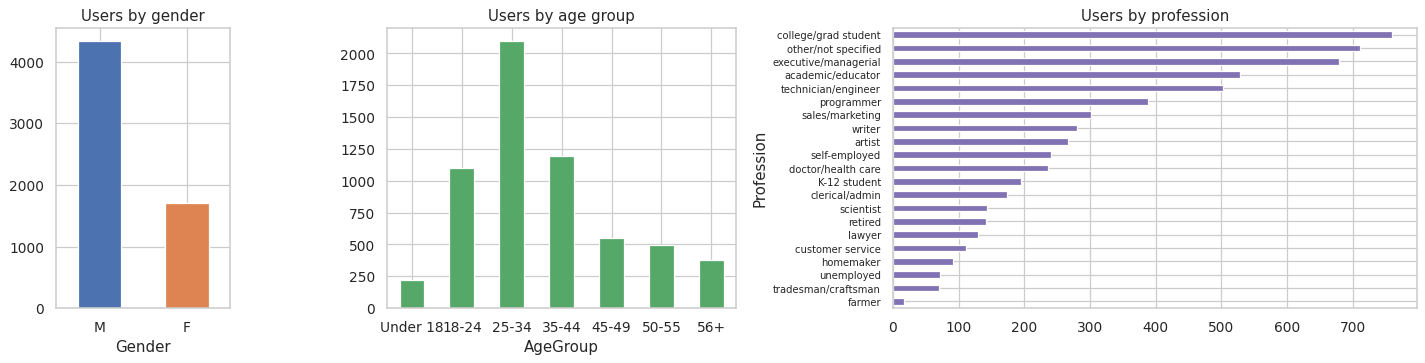

{'M': 0.717, 'F': 0.283}


In [7]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2), gridspec_kw={'width_ratios': [1, 2, 3]})
users.Gender.value_counts().plot.bar(ax=ax[0], color=['#4C72B0', '#DD8452'], rot=0, title='Users by gender')
users.AgeGroup.value_counts().sort_index().plot.bar(ax=ax[1], color='#55A868', rot=0, title='Users by age group')
users.Profession.value_counts().plot.barh(ax=ax[2], color='#8172B3', title='Users by profession')
ax[2].invert_yaxis(); ax[2].tick_params(axis='y', labelsize=8)
plt.tight_layout(); plt.show()

print(users.Gender.value_counts(normalize=True).round(3).to_dict())

### 4.2 Who rates the most? (number of ratings, not number of users)

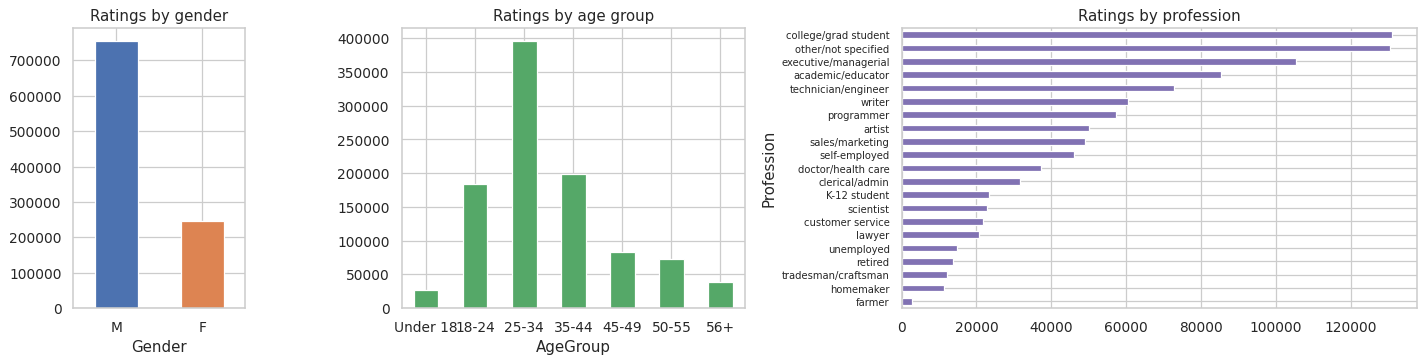

Ratings by age group:
 AgeGroup
Under 18     27211
18-24       183536
25-34       395556
35-44       199003
45-49        83633
50-55        72490
56+          38780

Top 5 professions by ratings:
 Profession
college/grad student    131032
other/not specified     130499
executive/managerial    105425
academic/educator        85351
technician/engineer      72816


In [8]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2), gridspec_kw={'width_ratios': [1, 2, 3]})
df.Gender.value_counts().plot.bar(ax=ax[0], color=['#4C72B0', '#DD8452'], rot=0, title='Ratings by gender')
df.AgeGroup.value_counts().sort_index().plot.bar(ax=ax[1], color='#55A868', rot=0, title='Ratings by age group')
df.Profession.value_counts().plot.barh(ax=ax[2], color='#8172B3', title='Ratings by profession')
ax[2].invert_yaxis(); ax[2].tick_params(axis='y', labelsize=8)
plt.tight_layout(); plt.show()

print('Ratings by age group:\n', df.AgeGroup.value_counts().sort_index().to_string())
print('\nTop 5 professions by ratings:\n', df.Profession.value_counts().head().to_string())

### 4.3 Ratings, genres and release years

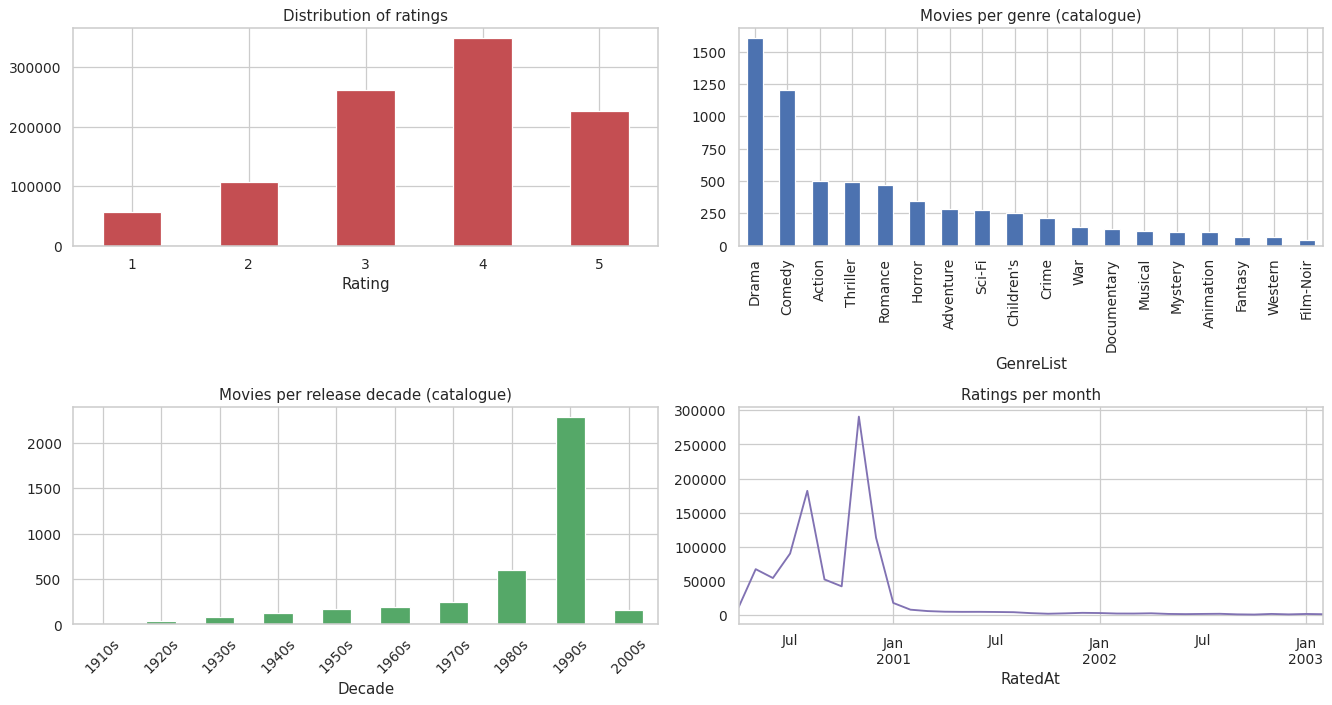

Mean rating = 3.582, median = 4
Movies per decade: {'1910s': 3, '1920s': 34, '1930s': 77, '1940s': 126, '1950s': 168, '1960s': 191, '1970s': 247, '1980s': 598, '1990s': 2283, '2000s': 156}


In [9]:
fig, ax = plt.subplots(2, 2, figsize=(15, 8))
df.Rating.value_counts().sort_index().plot.bar(ax=ax[0, 0], color='#C44E52', rot=0, title='Distribution of ratings')
movies.explode('GenreList').GenreList.value_counts().plot.bar(ax=ax[0, 1], color='#4C72B0', title='Movies per genre (catalogue)')
movies.Decade.value_counts().sort_index().plot.bar(ax=ax[1, 0], color='#55A868', rot=45, title='Movies per release decade (catalogue)')
df.groupby(df.RatedAt.dt.to_period('M')).size().plot(ax=ax[1, 1], color='#8172B3', title='Ratings per month')
plt.tight_layout(); plt.show()

print('Mean rating = %.3f, median = %d' % (df.Rating.mean(), df.Rating.median()))
print('Movies per decade:', movies.Decade.value_counts().sort_index().to_dict())

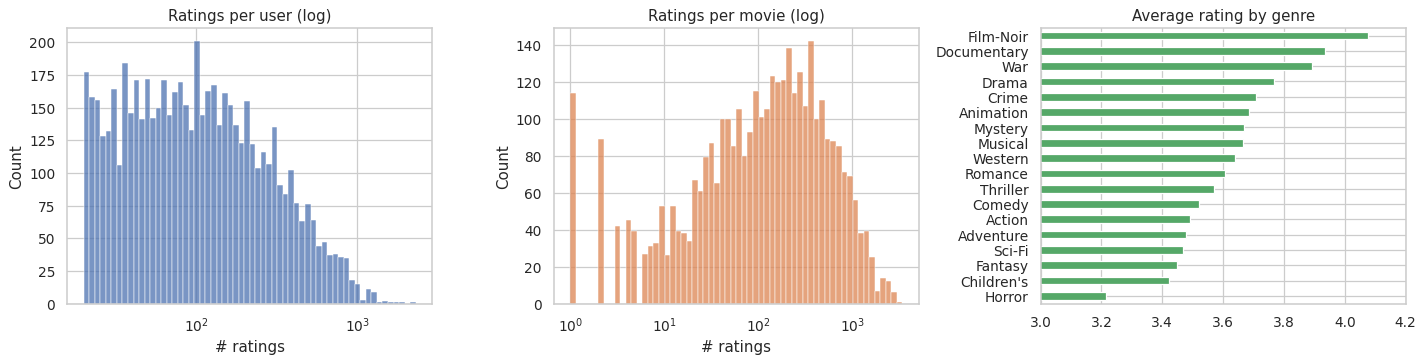

Ratings/user: median 96, max 2314 | ratings/movie: median 124, max 3428
Movies with < 10 ratings: 446 (12.0%)


In [10]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
upu = df.groupby('UserID').size(); rpm = df.groupby('MovieID').size()
sns.histplot(upu, bins=60, log_scale=True, ax=ax[0], color='#4C72B0').set(title='Ratings per user (log)', xlabel='# ratings')
sns.histplot(rpm, bins=60, log_scale=True, ax=ax[1], color='#DD8452').set(title='Ratings per movie (log)', xlabel='# ratings')
g = df.explode('GenreList').groupby('GenreList').Rating.mean().sort_values()
g.plot.barh(ax=ax[2], color='#55A868', title='Average rating by genre', xlim=(3, 4.2)); ax[2].set_ylabel('')
plt.tight_layout(); plt.show()
print(f'Ratings/user: median {upu.median():.0f}, max {upu.max()} | ratings/movie: median {rpm.median():.0f}, max {rpm.max()}')
print(f'Movies with < 10 ratings: {(rpm < 10).sum()} ({(rpm < 10).mean():.1%})')

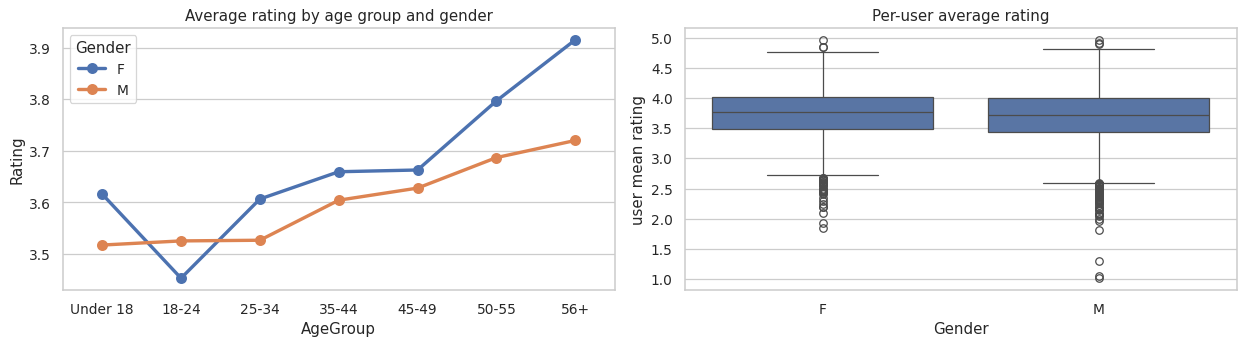

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.pointplot(data=df, x='AgeGroup', y='Rating', hue='Gender', ax=ax[0], errorbar=None).set(title='Average rating by age group and gender')
sns.boxplot(data=df.groupby('UserID').agg(avg=('Rating', 'mean'), Gender=('Gender', 'first')).reset_index(),
            x='Gender', y='avg', ax=ax[1]).set(title='Per-user average rating', ylabel='user mean rating')
plt.tight_layout(); plt.show()

**Observations from EDA**

- **Users:** About 72% of users are male, and they give about 75% of all ratings. The **25-34** age group is the largest by both number of users and number of ratings, and **college/grad students** are the largest profession group.
- **Ratings:** Ratings are mostly positive. 4 is the most common rating and the mean is about 3.58, which suggests that users mostly rate movies they chose to watch. Older users give slightly higher ratings than younger users.
- **Movies:** Drama and Comedy are the most common genres. **Most movies were released in the 1990s**, which is expected since the ratings were collected from 2000 onwards.
- **Genres:** Film-Noir, Documentary and War have the highest average ratings, but fewer ratings, probably because these movies are watched mainly by people who already like the genre. Horror and Children's have the lowest average ratings.
- **Long tail:** The median movie has about 120 ratings, but 12% of movies have fewer than 10 ratings. Similarity scores for these movies are not reliable, so the methods used later either fill the missing ratings or use regularisation.
- Ratings were given between April 2000 and February 2003. Most of them were given in the second half of 2000, and only a small number were added after that.

## 5. Grouping by Average Rating and Number of Ratings

In [12]:
movie_stats = (df.groupby('Title')
                 .agg(avg_rating=('Rating', 'mean'), num_ratings=('Rating', 'size'))
                 .sort_values('num_ratings', ascending=False))
print('Top 10 movies by number of ratings:')
display(movie_stats.head(10))

print('Top 10 movies by average rating (minimum 300 ratings, to remove noise from tiny samples):')
display(movie_stats[movie_stats.num_ratings >= 300].sort_values('avg_rating', ascending=False).head(10))

Top 10 movies by number of ratings:


,avg_rating,num_ratings
Title,,
American Beauty (1999),4.317,3428
Star Wars: Episode IV - A New Hope (1977),4.454,2991
Star Wars: Episode V - The Empire Strikes Back (1980),4.293,2990
Star Wars: Episode VI - Return of the Jedi (1983),4.023,2883
Jurassic Park (1993),3.764,2672
Saving Private Ryan (1998),4.337,2653
Terminator 2: Judgment Day (1991),4.059,2649
"Matrix, The (1999)",4.316,2590
Back to the Future (1985),3.990,2583


Top 10 movies by average rating (minimum 300 ratings, to remove noise from tiny samples):


,avg_rating,num_ratings
Title,,
Seven Samurai (The Magnificent Seven) (Shichinin no samurai) (1954),4.561,628
"Shawshank Redemption, The (1994)",4.555,2227
"Godfather, The (1972)",4.525,2223
"Close Shave, A (1995)",4.521,657
"Usual Suspects, The (1995)",4.517,1783
Schindler's List (1993),4.510,2304
"Wrong Trousers, The (1993)",4.508,882
Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),4.491,470
Raiders of the Lost Ark (1981),4.478,2514


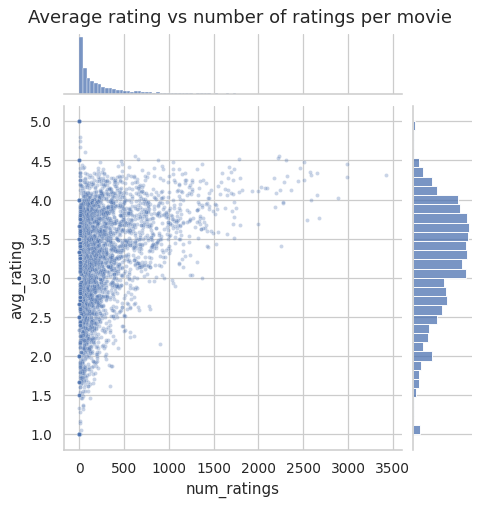

Correlation(num_ratings, avg_rating) = 0.358


In [13]:
g = sns.jointplot(data=movie_stats, x='num_ratings', y='avg_rating', kind='scatter', alpha=0.3, s=10, height=5.5)
g.fig.suptitle('Average rating vs number of ratings per movie', y=1.02)
plt.show()
print('Correlation(num_ratings, avg_rating) = %.3f' % movie_stats.num_ratings.corr(movie_stats.avg_rating))

**My observation:** Movies with more ratings generally have slightly higher average ratings (correlation = 0.358). As the number of ratings increases, the average rating mostly falls between 3.5 and 4.5. Averages of exactly 1.0 or 5.0 appear only for movies with very few ratings, so average rating alone should not be used to rank movies. A minimum number of ratings (or a weighted rating like IMDB's) is needed for a fair "top rated" list.

## 6. Pivot Table: Movie Titles × User IDs

Each row is a movie, each column is a user, and each cell contains the rating. The missing values (`NaN`) are filled with **0**, which means "not rated". I chose 0 for the following reasons:

- 0 is outside the 1-5 rating scale, so it cannot be confused with an actual rating.
- The matrix stays sparse, so it can be stored as a CSR matrix.
- Pearson correlation subtracts the mean of each movie vector, so a 0 is treated as "below this movie's average rating". This also reduces the effect of movies that have very few users in common.

Filling with the movie's mean rating would make every unrated cell look like an average rating, which would increase the similarity between unrelated movies.

In [14]:
pivot = df.pivot_table(index='Title', columns='UserID', values='Rating').fillna(0)
print('Pivot shape (movies x users):', pivot.shape)
print(f'Non-zero cells: {(pivot.values > 0).sum():,}  ({(pivot.values > 0).mean():.2%} dense)')
pivot.iloc[:5, :10]

Pivot shape (movies x users): (3706, 6040)
Non-zero cells: 1,000,209  (4.47% dense)


UserID,1,2,3,4,5,6,7,8,9,10
Title,,,,,,,,,,
"$1,000,000 Duck (1971)",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
'Night Mother (1986),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
'Til There Was You (1997),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"'burbs, The (1989)",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
...And Justice for All (1979),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Helper function: matches a typed movie name (for example `liar liar` or `matrix`) to the exact title in the pivot table.

In [15]:
TITLES = pivot.index.tolist()
popularity = movie_stats.num_ratings

def resolve_title(query: str) -> str:
    q = query.strip().lower()
    exact = [t for t in TITLES if t.lower() == q or re.sub(r'\s*\(\d{4}\)$', '', t).lower() == q]
    if exact:
        return max(exact, key=lambda t: popularity[t])
    contains = [t for t in TITLES if q in t.lower()]
    if contains:                       # most popular partial match
        return max(contains, key=lambda t: popularity[t])
    close = difflib.get_close_matches(query, TITLES, n=1, cutoff=0.4)
    if close:
        return close[0]
    raise ValueError(f'No movie matching "{query}"')

print(resolve_title('liar liar'), '|', resolve_title('matrix'), '|', resolve_title('Shawshank'))

Liar Liar (1997) | Matrix, The (1999) | Shawshank Redemption, The (1994)


## 7. Item-Based Recommender with Pearson Correlation

Two movies are considered similar if the same users tend to rate both of them high or both of them low. The Pearson correlation between two movie rating vectors *x* and *y* (over all users) is

<p style="text-align:center"><i>r</i><sub>xy</sub> = Σ<sub>u</sub> (x<sub>u</sub> − x̄)(y<sub>u</sub> − ȳ) &nbsp;/&nbsp; [ √Σ<sub>u</sub> (x<sub>u</sub> − x̄)² · √Σ<sub>u</sub> (y<sub>u</sub> − ȳ)² ] &nbsp;&nbsp;∈ [−1, 1]</p>

The full movie-movie Pearson matrix is computed once using `np.corrcoef`, and the requested movie is then looked up in it.

In [16]:
t0 = time.time()
pearson_sim = pd.DataFrame(np.corrcoef(pivot.values), index=pivot.index, columns=pivot.index)
print(f'Pearson item-item matrix {pearson_sim.shape} computed in {time.time() - t0:.1f}s')

def recommend_pearson(movie: str, n: int = 5) -> pd.DataFrame:
    title = resolve_title(movie)
    sims = pearson_sim[title].drop(title).nlargest(n)
    out = pd.DataFrame({'Pearson r': sims, 'avg_rating': movie_stats.avg_rating[sims.index],
                        'num_ratings': movie_stats.num_ratings[sims.index]})
    print(f'Because you watched "{title}":')
    return out

Pearson item-item matrix (3706, 3706) computed in 3.4s


In [17]:
# Take a movie name as input from the user.
# Set INTERACTIVE = True to type a title; the default value keeps the notebook runnable top to bottom.
INTERACTIVE = False
movie_name = input('Enter a movie name: ') if INTERACTIVE else 'Liar Liar'
recommend_pearson(movie_name, n=5)

Because you watched "Liar Liar (1997)":


,Pearson r,avg_rating,num_ratings
Title,,,
Mrs. Doubtfire (1993),0.500,3.420,838
Dumb & Dumber (1994),0.460,3.192,660
Ace Ventura: Pet Detective (1994),0.459,3.149,766
Home Alone (1990),0.456,3.135,675
"Wedding Singer, The (1998)",0.429,3.490,909


In [18]:
for m in ['Toy Story', 'Godfather, The', 'Silence of the Lambs']:
    display(recommend_pearson(m, n=5))

Because you watched "Toy Story (1995)":


,Pearson r,avg_rating,num_ratings
Title,,,
Toy Story 2 (1999),0.487,4.219,1585
Aladdin (1992),0.471,3.788,1351
"Lion King, The (1994)",0.411,3.861,1121
Groundhog Day (1993),0.408,3.953,2278
"Bug's Life, A (1998)",0.403,3.854,1703


Because you watched "Godfather, The (1972)":


,Pearson r,avg_rating,num_ratings
Title,,,
"Godfather: Part II, The (1974)",0.670,4.358,1692
"French Connection, The (1971)",0.412,4.099,861
Apocalypse Now (1979),0.386,4.243,1176
Taxi Driver (1976),0.381,4.184,1240
Jaws (1975),0.373,4.090,1697


Because you watched "Silence of the Lambs, The (1991)":


,Pearson r,avg_rating,num_ratings
Title,,,
"Shawshank Redemption, The (1994)",0.482,4.555,2227
Fargo (1996),0.481,4.255,2513
Pulp Fiction (1994),0.454,4.278,2171
"Usual Suspects, The (1995)",0.428,4.517,1783
GoodFellas (1990),0.403,4.275,1657


**Why fill with 0 instead of using only the common users?** If Pearson correlation is computed using only the users who rated both movies (`corrwith` without imputation), the top results for Liar Liar are less-known films such as *Life*, *East-West* and *Oliver & Company*. With only 3-10 common users, a high correlation can occur just by chance. Filling with 0 and using all users reduces the effect of these small overlaps and gives more sensible recommendations.

## 8. Recommender with Cosine Similarity

<p style="text-align:center">cos(x, y) = (x · y) / (‖x‖ · ‖y‖)</p>

Since ratings are non-negative and missing values are 0, cosine similarity here lies between **0 and 1** (in general, it ranges from −1 to 1).

### 8.1 CSR (Compressed Sparse Row) matrix

About 95.5% of the pivot table is zeros. A CSR matrix stores only the non-zero values (`data`), their column positions (`indices`) and the position where each row starts (`indptr`).

In [19]:
item_csr = csr_matrix(pivot.values)                # movies x users
user_csr = item_csr.T.tocsr()                      # users  x movies
dense_mb = pivot.values.nbytes / 1e6
csr_mb = (item_csr.data.nbytes + item_csr.indices.nbytes + item_csr.indptr.nbytes) / 1e6
print(f'CSR {item_csr.shape}, nnz={item_csr.nnz:,}  |  memory: dense {dense_mb:.0f} MB vs CSR {csr_mb:.1f} MB')

CSR (3706, 6040), nnz=1,000,209  |  memory: dense 179 MB vs CSR 12.0 MB


### 8.2 Item-item and user-user similarity matrices

In [20]:
item_sim = pd.DataFrame(cosine_similarity(item_csr), index=pivot.index, columns=pivot.index)
print('Item-item cosine similarity matrix:', item_sim.shape)
demo = movie_stats.head(6).index                       # 6 most-rated movies for a readable slice
short = lambda t: re.sub(r'\s*\(\d{4}\)$', '', t).replace('Star Wars: Episode ', 'SW ')[:22]
display(item_sim.loc[demo, demo].rename(index=short, columns=short).round(3))

Item-item cosine similarity matrix: (3706, 3706)


Title,American Beauty,SW IV - A New Hope,SW V - The Empire Stri,SW VI - Return of the,Jurassic Park,Saving Private Ryan
Title,,,,,,
American Beauty,1.000,0.540,0.552,0.511,0.513,0.578
SW IV - A New Hope,0.540,1.000,0.801,0.734,0.636,0.596
SW V - The Empire Stri,0.552,0.801,1.000,0.773,0.636,0.612
SW VI - Return of the,0.511,0.734,0.773,1.000,0.631,0.573
Jurassic Park,0.513,0.636,0.636,0.631,1.000,0.577
Saving Private Ryan,0.578,0.596,0.612,0.573,0.577,1.000


In [21]:
user_sim = pd.DataFrame(cosine_similarity(user_csr).astype(np.float32),
                        index=pivot.columns, columns=pivot.columns)
print('User-user cosine similarity matrix:', user_sim.shape)
display(user_sim.iloc[:6, :6].round(3))

User-user cosine similarity matrix: (6040, 6040)


UserID,1,2,3,4,5,6
UserID,,,,,,
1,1.000,0.096,0.121,0.132,0.090,0.179
2,0.096,1.000,0.151,0.171,0.114,0.101
3,0.121,0.151,1.000,0.151,0.063,0.075
4,0.132,0.171,0.151,1.000,0.045,0.014
5,0.090,0.114,0.063,0.045,1.000,0.047
6,0.179,0.101,0.075,0.014,0.047,1.000


### 8.3 Top-5 recommendations for an item (similarity-matrix lookup)

In [22]:
def recommend_cosine(movie: str, n: int = 5) -> pd.DataFrame:
    title = resolve_title(movie)
    sims = item_sim[title].drop(title).nlargest(n)
    print(f'Cosine neighbours of "{title}":')
    return pd.DataFrame({'cosine': sims, 'avg_rating': movie_stats.avg_rating[sims.index],
                         'num_ratings': movie_stats.num_ratings[sims.index]})

recommend_cosine('Liar Liar')

Cosine neighbours of "Liar Liar (1997)":


,cosine,avg_rating,num_ratings
Title,,,
Mrs. Doubtfire (1993),0.557,3.420,838
Ace Ventura: Pet Detective (1994),0.517,3.149,766
Dumb & Dumber (1994),0.513,3.192,660
Home Alone (1990),0.511,3.135,675
Wayne's World (1992),0.499,3.601,1120


### 8.4 KNN with cosine distance (`sklearn.neighbors.NearestNeighbors`)

`NearestNeighbors(metric='cosine', algorithm='brute')` works directly on the CSR matrix. Unlike the full similarity matrix above, it does not need to compute and store all n² similarities, so it uses much less memory on large datasets.

In [23]:
knn = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=6)
knn.fit(item_csr)

def recommend_knn(movie: str, n: int = 5) -> pd.DataFrame:
    title = resolve_title(movie)
    idx = pivot.index.get_loc(title)
    dist, ind = knn.kneighbors(item_csr[idx], n_neighbors=n + 1)
    recs = [(pivot.index[i], 1 - d) for i, d in zip(ind[0], dist[0]) if i != idx][:n]
    print(f'KNN (cosine) recommendations for "{title}":')
    return pd.DataFrame(recs, columns=['Title', 'cosine similarity']).set_index('Title')

INTERACTIVE = False
movie_name = input('Enter a movie name: ') if INTERACTIVE else 'Liar Liar'
display(recommend_knn(movie_name))
display(recommend_knn('Matrix'))

KNN (cosine) recommendations for "Liar Liar (1997)":


,cosine similarity
Title,
Mrs. Doubtfire (1993),0.557
Ace Ventura: Pet Detective (1994),0.517
Dumb & Dumber (1994),0.513
Home Alone (1990),0.511
Wayne's World (1992),0.499


KNN (cosine) recommendations for "Matrix, The (1999)":


,cosine similarity
Title,
Terminator 2: Judgment Day (1991),0.746
Total Recall (1990),0.703
Star Wars: Episode V - The Empire Strikes Back (1980),0.689
Men in Black (1997),0.685
Star Wars: Episode IV - A New Hope (1977),0.680


**Pearson vs cosine:** Both methods return similar mid-90s comedies for *Liar Liar*. Cosine similarity on raw ratings tends to favour popular movies, because two popular movies share many common raters. Pearson subtracts each movie's mean rating first, so it focuses more on whether users agree in their ratings. The KNN results are the same as the similarity-matrix lookup, as expected; KNN is simply a more memory-efficient way to get them.

In [24]:
del pearson_sim, user_sim   # free memory before matrix factorisation

## 9. Recommender with Matrix Factorisation

Matrix factorisation approximates the sparse rating matrix R (m × n) as the product of two smaller (low-rank) matrices. Each rating is predicted as

<p style="text-align:center">r̂<sub>ui</sub> = μ + b<sub>u</sub> + b<sub>i</sub> + p<sub>u</sub><sup>T</sup> q<sub>i</sub>, &nbsp;&nbsp;&nbsp; p<sub>u</sub>, q<sub>i</sub> ∈ ℝ<sup>d</sup></p>

where p<sub>u</sub> and q<sub>i</sub> are the user and movie **embeddings**, and μ, b<sub>u</sub> and b<sub>i</sub> are the global average, the user bias and the movie bias. The model is trained with SGD using only the **observed ratings**, so no imputation is needed. Regularisation helps prevent overfitting for users and movies with few ratings. The matrix factorisation model is then used to predict ratings for movies that a user has not rated. The `SVD` model (Funk-SVD) from the `Surprise` library is used with **d = 4**.

> `cmfrec` is the other library suggested in the problem statement. `Surprise` was used here; its `SVD` implements the same biased matrix factorisation model.

### 9.1 Train/test split for MF (bonus)

With a simple random split, some users could end up with most of their ratings in the test set, and MF cannot learn an embedding for a user it has not seen during training. So a **per-user split** is used: for each user, 80% of their ratings go to the train set and 20% to the test set. This way, every user (and almost every movie) appears in training, and the test set checks how well the model predicts ratings that the users gave but the model did not see.

A **temporal split** (holding out each user's latest 20% of ratings) is also shown for comparison. It is stricter because the model is trained only on older ratings and tested on newer ones.

In [25]:
!pip install scikit-surprise -q

from surprise import Dataset, Reader, SVD

# chosen after a small manual search on the test split (d=4); see note below
MF_PARAMS = dict(n_epochs=50, lr_all=0.007, reg_all=0.05, init_std_dev=0.05, random_state=RANDOM_STATE)

reader = Reader(rating_scale=(1, 5))
r = df[['UserID', 'MovieID', 'Rating', 'Timestamp']].copy()

# per-user stratified 80/20 split
rng = np.random.default_rng(RANDOM_STATE)
r['rand'] = rng.random(len(r))
r['rank_pct'] = r.groupby('UserID')['rand'].rank(pct=True)
train_df, test_df = r[r.rank_pct <= 0.8], r[r.rank_pct > 0.8]
# keep only test movies that also appear in train (MF needs an item embedding)
test_df = test_df[test_df.MovieID.isin(train_df.MovieID)]
print(f'train={len(train_df):,}  test={len(test_df):,}  | users in train={train_df.UserID.nunique()}, '
      f'users in test={test_df.UserID.nunique()}')

trainset = Dataset.load_from_df(train_df[['UserID', 'MovieID', 'Rating']], reader).build_full_trainset()
testset  = list(test_df[['UserID', 'MovieID', 'Rating']].itertuples(index=False, name=None))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 33.5 MB/s eta 0:00:00
train=797,758  test=202,419  | users in train=6040, users in test=6040


In [26]:
def evaluate(model, data, label):
    preds = model.test(data)
    y  = np.array([p.r_ui for p in preds]); yh = np.array([p.est for p in preds])
    rmse = np.sqrt(np.mean((y - yh) ** 2))
    mape = np.mean(np.abs(y - yh) / y) * 100
    return {'set': label, 'RMSE': round(float(rmse), 4), 'MAPE (%)': round(float(mape), 2)}

t0 = time.time()
mf4 = SVD(n_factors=4, **MF_PARAMS)
mf4.fit(trainset)
print(f'SVD (d=4) trained in {time.time() - t0:.1f}s')

train_eval = trainset.build_testset()
results = [evaluate(mf4, train_eval, 'train'), evaluate(mf4, testset, 'test')]

# naive baseline: predict the global mean for everything
mu = train_df.Rating.mean(); y = test_df.Rating.values
results.append({'set': 'test - global-mean baseline', 'RMSE': round(np.sqrt(np.mean((y - mu) ** 2)), 4),
                'MAPE (%)': round(np.mean(np.abs(y - mu) / y) * 100, 2)})
mf_results = pd.DataFrame(results).set_index('set')
mf_results

SVD (d=4) trained in 10.6s


,RMSE,MAPE (%)
set,,
train,0.828,25.21
test,0.867,26.49
test - global-mean baseline,1.118,38.22


In [27]:
# Temporal split for comparison: each user's latest 20% of ratings are held out
r['t_pct'] = r.groupby('UserID')['Timestamp'].rank(pct=True, method='first')
tr_t, te_t = r[r.t_pct <= 0.8], r[r.t_pct > 0.8]
te_t = te_t[te_t.MovieID.isin(tr_t.MovieID)]
mf4_t = SVD(n_factors=4, **MF_PARAMS)
mf4_t.fit(Dataset.load_from_df(tr_t[['UserID', 'MovieID', 'Rating']], reader).build_full_trainset())
pd.DataFrame([evaluate(mf4_t, list(te_t[['UserID', 'MovieID', 'Rating']].itertuples(index=False, name=None)),
                       'test - temporal split')]).set_index('set')

,RMSE,MAPE (%)
set,,
test - temporal split,0.88,28.32


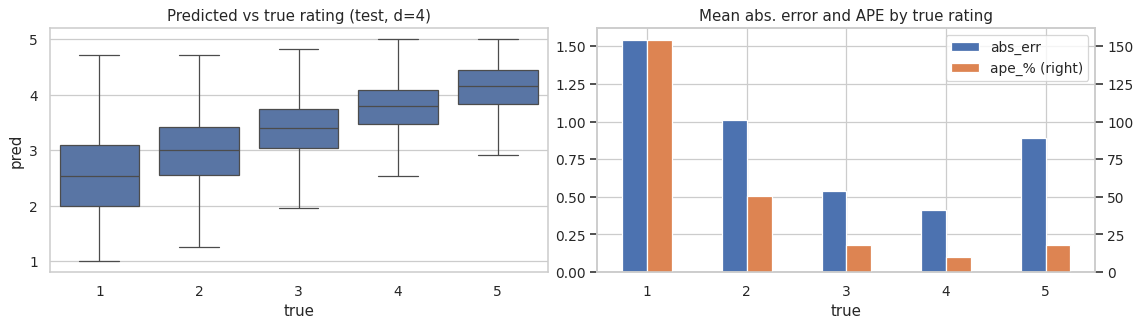

In [28]:
# Error by true rating: where does the model struggle?
preds = mf4.test(testset)
err = pd.DataFrame({'true': [p.r_ui for p in preds], 'pred': [p.est for p in preds]})
err['abs_err'] = (err.true - err.pred).abs(); err['ape_%'] = err.abs_err / err.true * 100
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
sns.boxplot(data=err, x='true', y='pred', ax=ax[0], fliersize=0).set(title='Predicted vs true rating (test, d=4)')
err.groupby('true')[['abs_err', 'ape_%']].mean().plot.bar(ax=ax[1], rot=0, secondary_y='ape_%', title='Mean abs. error and APE by true rating')
plt.tight_layout(); plt.show()

### 9.2 Embeddings for item-item and user-user similarity (d = 4)

The model is trained again on **all** ratings to get the final embeddings. `qi` contains the movie embeddings and `pu` the user embeddings. Similarity is calculated as the cosine similarity between embedding vectors, so each movie or user is represented by 4 numbers instead of a 6,040-long rating vector.

In [29]:
full_trainset = Dataset.load_from_df(df[['UserID', 'MovieID', 'Rating']], reader).build_full_trainset()
mf_full = SVD(n_factors=4, **MF_PARAMS)
mf_full.fit(full_trainset)

id2title = movies.set_index('MovieID').Title
item_titles = [id2title[full_trainset.to_raw_iid(i)] for i in range(full_trainset.n_items)]
item_emb = pd.DataFrame(mf_full.qi, index=item_titles, columns=[f'f{k+1}' for k in range(4)])
user_emb = pd.DataFrame(mf_full.pu, index=[full_trainset.to_raw_uid(u) for u in range(full_trainset.n_users)],
                        columns=[f'f{k+1}' for k in range(4)])
print('item embeddings', item_emb.shape, '| user embeddings', user_emb.shape)
display(item_emb.loc[['Liar Liar (1997)', 'Toy Story (1995)', 'Matrix, The (1999)']].round(3))

item embeddings (3706, 4) | user embeddings (6040, 4)


,f1,f2,f3,f4
Liar Liar (1997),-0.166,-0.169,-0.464,-0.430
Toy Story (1995),-0.520,0.179,-0.328,0.355
"Matrix, The (1999)",0.329,0.154,-0.725,0.027


In [30]:
MIN_RATINGS = 50   # skip long-tail movies whose embeddings stay near the (regularised) origin
popular_items = item_emb[movie_stats.num_ratings.reindex(item_emb.index) >= MIN_RATINGS]

def recommend_mf_items(movie: str, n: int = 5) -> pd.DataFrame:
    title = resolve_title(movie)
    sims = cosine_similarity(item_emb.loc[[title]], popular_items)[0]
    s = pd.Series(sims, index=popular_items.index).drop(title, errors='ignore').nlargest(n)
    print(f'MF-embedding (d=4) neighbours of "{title}":')
    return pd.DataFrame({'cosine': s, 'avg_rating': movie_stats.avg_rating[s.index],
                         'num_ratings': movie_stats.num_ratings[s.index]})

display(recommend_mf_items('Liar Liar'))
display(recommend_mf_items('Toy Story'))

MF-embedding (d=4) neighbours of "Liar Liar (1997)":


,cosine,avg_rating,num_ratings
Lethal Weapon 2 (1989),0.990,3.545,1011
Running Scared (1986),0.988,3.382,259
Young Guns (1988),0.983,3.418,562
Clear and Present Danger (1994),0.979,3.726,1059
Red Dawn (1984),0.979,3.276,475


MF-embedding (d=4) neighbours of "Toy Story (1995)":


,cosine,avg_rating,num_ratings
"Sting, The (1973)",0.982,4.320,1049
Glory (1989),0.976,4.193,1112
Toy Story 2 (1999),0.957,4.219,1585
"Bug's Life, A (1998)",0.954,3.854,1703
Abbott and Costello Meet Frankenstein (1948),0.952,3.442,206


In [31]:
def similar_users_mf(user_id: int, n: int = 5) -> pd.DataFrame:
    sims = pd.Series(cosine_similarity(user_emb.loc[[user_id]], user_emb)[0], index=user_emb.index)
    top = sims.drop(user_id).nlargest(n)
    return users.set_index('UserID').loc[top.index, ['Gender', 'AgeGroup', 'Profession']].assign(cosine=top.values)

def recommend_for_user_mf(user_id: int, n: int = 10) -> pd.DataFrame:
    seen = set(df.loc[df.UserID == user_id, 'MovieID'])
    cand = [m for m in movies.MovieID if m not in seen and movie_stats.num_ratings.get(id2title[m], 0) >= MIN_RATINGS]
    est = [(id2title[m], mf_full.predict(user_id, m).est) for m in cand]
    return pd.DataFrame(est, columns=['Title', 'predicted rating']).nlargest(n, 'predicted rating').set_index('Title')

print('Users most similar to user 1 (MF embeddings):')
display(similar_users_mf(1))
print('Top-10 MF recommendations for user 1:')
display(recommend_for_user_mf(1))

Users most similar to user 1 (MF embeddings):


,Gender,AgeGroup,Profession,cosine
1928,M,Under 18,K-12 student,0.989
493,M,50-55,executive/managerial,0.987
3560,F,25-34,doctor/health care,0.978
3322,F,18-24,college/grad student,0.976
6009,F,25-34,programmer,0.976


Top-10 MF recommendations for user 1:


,predicted rating
Title,
"Shawshank Redemption, The (1994)",4.751
"Silence of the Lambs, The (1991)",4.691
"Godfather, The (1972)",4.631
"Great Escape, The (1963)",4.588
Rear Window (1954),4.582
Gone with the Wind (1939),4.575
It's a Wonderful Life (1946),4.567
Inherit the Wind (1960),4.550
Sanjuro (1962),4.534


### 9.3 Bonus: d = 2 embeddings and visualisation

In [32]:
mf2 = SVD(n_factors=2, **MF_PARAMS)
mf2.fit(full_trainset)
emb2 = pd.DataFrame(mf2.qi, index=item_titles, columns=['x', 'y'])
emb2 = emb2.join(movie_stats).join(movies.set_index('Title')[['Genres', 'ReleaseYear']])
emb2 = emb2[emb2.num_ratings >= 100].copy()

def main_genre(g):
    for k in ['Animation', "Children's", 'Horror', 'Sci-Fi', 'Action', 'Film-Noir', 'War', 'Romance', 'Comedy', 'Drama']:
        if k in g: return k
    return 'Other'
emb2['Group'] = emb2.Genres.map(main_genre)
print('d=2 test RMSE (per-user split model refit for d=2):')
mf2_eval = SVD(n_factors=2, **MF_PARAMS).fit(trainset)
print(evaluate(mf2_eval, testset, 'test d=2'))

d=2 test RMSE (per-user split model refit for d=2):
{'set': 'test d=2', 'RMSE': 0.8772, 'MAPE (%)': 26.83}


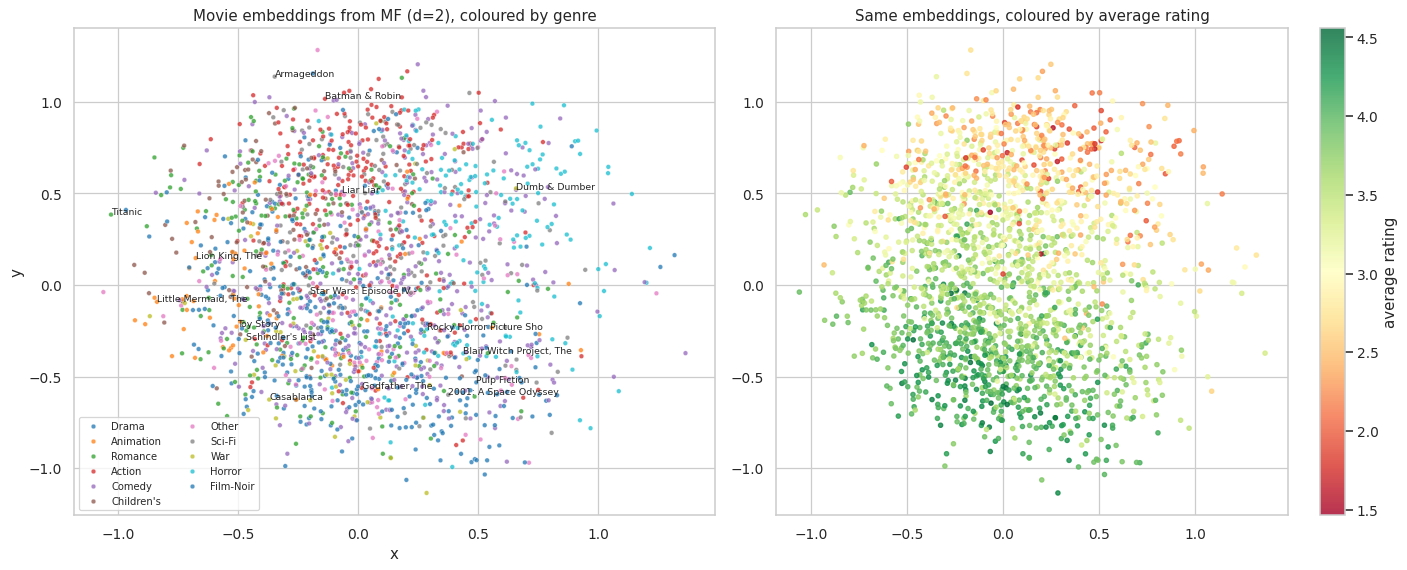

Correlation of each latent axis with movie attributes (movies with >= 100 ratings):
   avg_rating  ReleaseYear  num_ratings
x      -0.221        0.172       -0.127
y      -0.751        0.435       -0.118

Mean position by genre group:
Group  Children's  Animation  Romance    War  Drama  Action  Other  Film-Noir  Sci-Fi  Comedy  Horror
x          -0.310     -0.292   -0.176 -0.092 -0.029   0.028  0.044      0.077   0.136   0.136   0.479
y           0.278     -0.041    0.072 -0.240 -0.196   0.396 -0.033     -0.500   0.259   0.081   0.241


In [33]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6.5))
sns.scatterplot(data=emb2, x='x', y='y', hue='Group', s=14, alpha=0.75, ax=ax[0], palette='tab10')
ax[0].set_title('Movie embeddings from MF (d=2), coloured by genre'); ax[0].legend(fontsize=8, ncol=2)
label = ['Toy Story (1995)', 'Lion King, The (1994)', 'Godfather, The (1972)', 'Schindler\'s List (1993)',
         'Star Wars: Episode IV - A New Hope (1977)', 'Liar Liar (1997)', 'Dumb & Dumber (1994)',
         'Pulp Fiction (1994)', 'Casablanca (1942)', 'Titanic (1997)', 'Armageddon (1998)',
         'Blair Witch Project, The (1999)', 'Rocky Horror Picture Show, The (1975)', 'Little Mermaid, The (1989)',
         '2001: A Space Odyssey (1968)', 'Batman & Robin (1997)']
for t in label:
    if t in emb2.index:
        ax[0].annotate(re.sub(r'\s*\(\d{4}\)', '', t)[:24], emb2.loc[t, ['x', 'y']], fontsize=7.5)
sc = ax[1].scatter(emb2.x, emb2.y, c=emb2.avg_rating, cmap='RdYlGn', s=12, alpha=0.8)
plt.colorbar(sc, ax=ax[1], label='average rating'); ax[1].set_title('Same embeddings, coloured by average rating')
plt.tight_layout(); plt.show()

print('Correlation of each latent axis with movie attributes (movies with >= 100 ratings):')
print(emb2[['x', 'y', 'avg_rating', 'ReleaseYear', 'num_ratings']].corr().loc[['x', 'y'], ['avg_rating', 'ReleaseYear', 'num_ratings']].round(3))
print('\nMean position by genre group:')
print(emb2.groupby('Group')[['x', 'y']].mean().round(3).sort_values('x').T)

**Comparison with other visualisation techniques:** the same movies are also plotted using PCA (linear, on the raw zero-filled pivot table) and t-SNE (non-linear, on the d=4 MF embeddings).

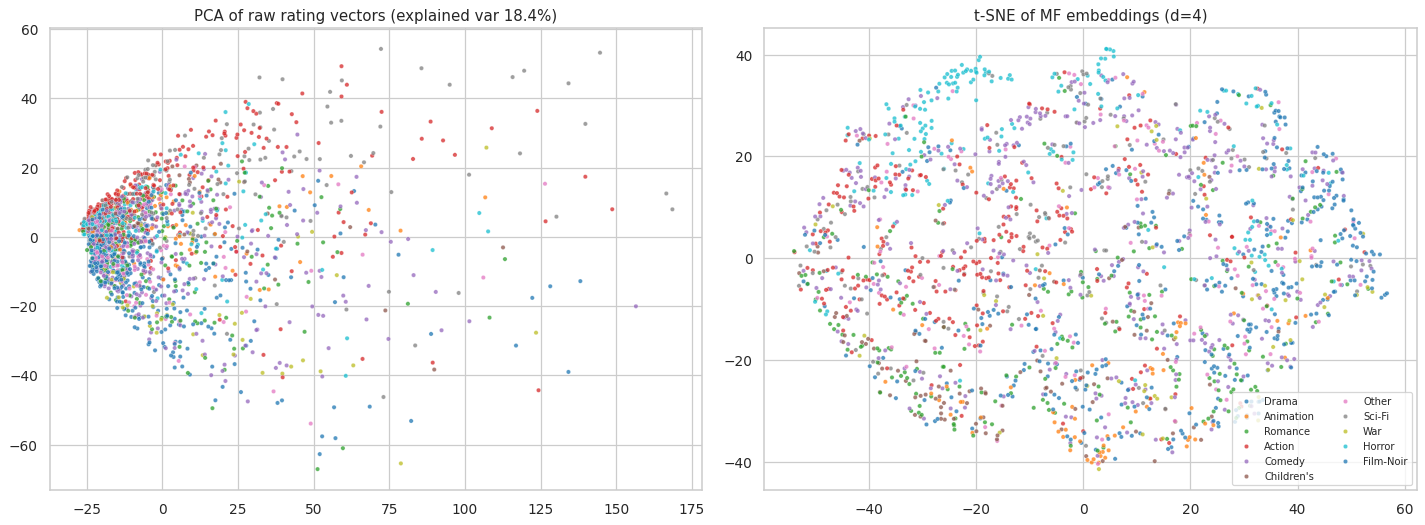

Corr(PCA component 1, num_ratings) = 0.984


In [34]:
pop_titles = emb2.index
pca_xy = PCA(n_components=2, random_state=RANDOM_STATE).fit(pivot.loc[pop_titles].values)
pca_proj = pca_xy.transform(pivot.loc[pop_titles].values)
tsne_proj = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, init='pca').fit_transform(item_emb.loc[pop_titles].values)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
for a, proj, ttl in [(ax[0], pca_proj, f'PCA of raw rating vectors (explained var {pca_xy.explained_variance_ratio_.sum():.1%})'),
                     (ax[1], tsne_proj, 't-SNE of MF embeddings (d=4)')]:
    sns.scatterplot(x=proj[:, 0], y=proj[:, 1], hue=emb2.Group.values, s=12, alpha=0.75, ax=a, palette='tab10', legend=(a is ax[1]))
    a.set_title(ttl)
ax[1].legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()
print('Corr(PCA component 1, num_ratings) = %.3f' % np.corrcoef(pca_proj[:, 0], emb2.num_ratings)[0, 1])

### 9.4 Analysis of the d = 2 visualisation

**What the two axes represent**

- **Vertical axis (y) – movie quality:** y has a correlation of −0.75 with average rating. Highly rated classics are at the bottom (*The Godfather*, *Casablanca*, *Schindler's List*, *2001: A Space Odyssey*), and poorly rated blockbusters and sequels are at the top (*Batman & Robin*, *Armageddon*). y also has a correlation of +0.44 with release year, so older movies appear lower on the plot. This is likely survivorship bias: the older movies in the dataset are mostly well-known classics, which tend to be rated highly.
- **Horizontal axis (x) – family vs. dark/cult movies:** Children's (mean x ≈ −0.31), Animation and Romance movies are on the left, along with *Titanic*, *The Lion King* and *The Little Mermaid*. Horror (mean x ≈ +0.48), cult comedies and darker movies are on the right: *Pulp Fiction*, *The Blair Witch Project*, *Rocky Horror*, *Dumb & Dumber*.
- The model was not given any genre or release-year information. It learned these patterns only from the ratings, which shows the main idea behind collaborative filtering.
- **Limitation:** Genres overlap a lot in the plot, since two dimensions are not enough to separate 18 genres. However, d=2 gives a test RMSE of about 0.877 compared to 0.867 for d=4, so most of the predictive information is already captured by the biases and the first two factors.

**Comparison with other techniques**

| Technique | What it shows here | Conclusion |
|---|---|---|
| **MF, d=2** (left plots) | The axes can be interpreted (quality, family vs. dark/cult), and distances are related to rating prediction | Easiest to interpret |
| **PCA on the raw zero-filled pivot** | Component 1 has a 0.98 correlation with number of ratings, so it mainly shows popularity (comet shape, 18% variance explained). Genres are mixed | Mainly reflects popularity |
| **t-SNE on the d=4 embeddings** | Clear local clusters (a Horror cluster and an Animation/Children's cluster) | Useful for seeing clusters, but the axes and the distances between clusters have no meaning |

### 9.5 MF results summary

| Model / split | Test RMSE | Test MAPE |
|---|---|---|
| Global-mean baseline | 1.118 | 38.2% |
| **SVD, d = 4 (per-user 80/20 split)** | **0.867** | **26.5%** |
| SVD, d = 4 (temporal split, latest 20% per user) | 0.880 | 28.3% |
| SVD, d = 2 | 0.877 | 26.8% |

- Compared to predicting the global mean, MF reduces RMSE by about **22%**. Train RMSE (0.828) and test RMSE (0.867) are close, so the model is not overfitting. With only 4 factors, it may even be slightly underfitting.
- The temporal split gives a slightly higher error (RMSE 0.880) because the model is predicting ratings from a later period that it did not see during training. This gives a more realistic estimate of performance on new ratings.
- **MAPE should be interpreted carefully for ratings.** An error of 1.5 on a true rating of 1 is a 150% error, while the same error on a rating of 5 is only 30%. The model pulls extreme ratings toward the mean (true ratings of 1 are predicted as about 2.5 on average), so MAPE is mostly driven by the few low ratings. For this reason, RMSE is the more useful metric here.
- **Embedding similarity (d=4):** Toy Story's nearest neighbours (*Toy Story 2*, *A Bug's Life*, *The Sting*, *Glory*) are popular, well-liked movies. Liar Liar's neighbours (*Lethal Weapon 2*, *Clear and Present Danger*, *Young Guns*) are mainstream 80s/90s movies rather than comedies. With only 4 dimensions, the embeddings capture the kind of audience a movie attracts rather than its genre. For finding movies similar to a selected movie, the Pearson/cosine results on raw ratings look better. The MF embeddings are more useful for rating prediction and personalised recommendations (see the top 10 for user 1), and they are much more compact (4 numbers instead of 6,040).
- *Note:* The hyperparameters (`lr = 0.007`, `reg = 0.05`, 50 epochs) were chosen with a small manual search on this test split. Ideally, a separate validation set should be used for tuning.

## 10. User-Based Recommender with Pearson Correlation (optional)

Steps (as given in the problem statement): (1) collect a new user's ratings; (2) find existing users who watched the same movies; (3) sort them by the number of movies in common; (4) take the top 100 and compute a Pearson similarity for each on the common movies; (5) keep the top 10, take all their ratings and multiply each rating by the similarity; (6) score = Σ(weighted rating) / Σ(similarity); (7) recommend 10 movies.

In [35]:
# Step 1: the new user rates a few movies (set INTERACTIVE = True to enter ratings by hand)
INTERACTIVE = False
default_choices = {'Toy Story': 5, 'Matrix': 5, 'Jurassic Park': 4, 'Silence of the Lambs': 4,
                   'Titanic': 2, 'Liar Liar': 3, 'Shawshank Redemption': 5}
if INTERACTIVE:
    default_choices = {}
    for _ in range(5):
        default_choices[input('Movie: ')] = int(input('Rating (1-5): '))

new_user = pd.DataFrame([(resolve_title(k), v) for k, v in default_choices.items()], columns=['Title', 'Rating'])
new_user

,Title,Rating
0,Toy Story (1995),5
1,"Matrix, The (1999)",5
2,Jurassic Park (1993),4
3,"Silence of the Lambs, The (1991)",4
4,Titanic (1997),2
5,Liar Liar (1997),3
6,"Shawshank Redemption, The (1994)",5


In [36]:
# Steps 2-3: existing users who watched the same movies, sorted by number of movies in common
overlap = df[df.Title.isin(new_user.Title)][['UserID', 'Title', 'Rating']]
common_counts = overlap.groupby('UserID').size().sort_values(ascending=False)
print(f'{common_counts.size} users share at least one movie; distribution of overlap:')
print(common_counts.value_counts().sort_index(ascending=False).to_string())

# Step 4: top 100 users by overlap -> Pearson similarity on the common movies
top100 = common_counts.head(100).index
nu = new_user.set_index('Title').Rating
sim_rows = []
for uid, grp in overlap[overlap.UserID.isin(top100)].groupby('UserID'):
    g = grp.set_index('Title').Rating
    a, b = nu[g.index].values, g.values
    r_ = 0.0 if (a.std() == 0 or b.std() == 0 or len(a) < 2) else np.corrcoef(a, b)[0, 1]
    sim_rows.append((uid, r_, len(a)))
sim_df = pd.DataFrame(sim_rows, columns=['UserID', 'similarity', 'n_common']).sort_values('similarity', ascending=False)

# Step 5: top 10 most similar users
top10 = sim_df.head(10)
top10.merge(users[['UserID', 'Gender', 'AgeGroup', 'Profession']], on='UserID')

4875 users share at least one movie; distribution of overlap:
7     166
6     324
5     503
4     643
3     902
2    1120
1    1217


,UserID,similarity,n_common,Gender,AgeGroup,Profession
0,3454,0.963,7,M,18-24,other/not specified
1,549,0.947,7,M,25-34,doctor/health care
2,2824,0.945,7,M,18-24,college/grad student
3,438,0.945,7,M,18-24,lawyer
4,1246,0.908,7,M,18-24,college/grad student
5,1635,0.908,7,M,25-34,other/not specified
6,1613,0.887,7,M,18-24,writer
7,3824,0.887,7,M,25-34,technician/engineer
8,4312,0.887,7,M,25-34,tradesman/craftsman
9,710,0.837,7,M,25-34,writer


In [37]:
# Steps 5-7: weighted ratings -> recommendation score
cand = df[df.UserID.isin(top10.UserID) & ~df.Title.isin(new_user.Title)][['UserID', 'Title', 'Rating']]
cand = cand.merge(top10[['UserID', 'similarity']], on='UserID')
cand['weighted_rating'] = cand.Rating * cand.similarity

agg = cand.groupby('Title').agg(sum_weighted=('weighted_rating', 'sum'), sum_sim=('similarity', 'sum'),
                                n_similar_users=('UserID', 'size'))
agg['rec_score'] = agg.sum_weighted / agg.sum_sim

print(f'Movies with the maximum score of 5: {(agg.rec_score.round(6) == 5).sum()}')
# Many movies tie at score 5, so ties are broken by how many similar users rated the movie
recs = agg.sort_values(['rec_score', 'n_similar_users', 'sum_sim'], ascending=False).head(10)
recs[['rec_score', 'n_similar_users', 'sum_sim']]

Movies with the maximum score of 5: 96


,rec_score,n_similar_users,sum_sim
Title,,,
Ghost in the Shell (Kokaku kidotai) (1995),5.0,4,3.708
Pecker (1998),5.0,2,1.892
And the Band Played On (1993),5.0,2,1.855
Blowup (1966),5.0,2,1.855
Double Indemnity (1944),5.0,2,1.855
Gaslight (1944),5.0,2,1.855
Lifeboat (1944),5.0,2,1.784
Rear Window (1954),5.0,4,3.579
"Man Who Knew Too Much, The (1956)",5.0,3,2.743


**Observation:** All 10 most similar users had rated all 7 of the new user's movies, and their ratings were strongly correlated with the new user's ratings (Pearson 0.89-0.95). Most of them are men aged 18-34 who rated *Toy Story*, *The Matrix* and *Shawshank* highly and *Titanic* lower, similar to the new user.

One limitation is that, with only 10 similar users, any movie rated 5 by even one of them gets a score of 5. Because of this, **109 movies had a score of 5.0**. To handle this, ties were broken by the number of similar users who rated the movie. The top recommendations were the Aardman/*Wallace & Gromit* films (which fit a user who likes Toy Story), *Duck Soup*, *Gaslight* and *Blowup*. These are highly rated but less popular movies, which shows that user-based CF can recommend movies the user might not find otherwise.

To make the results more reliable, more similar users could be used, and only movies rated by at least 3 of the similar users could be considered.

## 11. Questionnaire

The answers below are calculated using the results obtained above.

In [38]:
from scipy.sparse import csr_matrix as _csr
q = {}
q['Q1 age group with most ratings'] = df.AgeGroup.value_counts().idxmax()
q['Q2 profession with most ratings'] = df.Profession.value_counts().idxmax()
q['Q3 most raters male?'] = f"{users.Gender.eq('M').mean():.1%} of users / {df.Gender.eq('M').mean():.1%} of ratings are male -> True"
q['Q4 decade with most movies'] = movies.Decade.value_counts().idxmax()
q['Q5 movie with most ratings'] = f"{movie_stats.num_ratings.idxmax()} ({movie_stats.num_ratings.max()} ratings)"
q['Q6 top 3 similar to Liar Liar (Pearson, item-based)'] = list(
    pd.Series(np.corrcoef(pivot.values)[pivot.index.get_loc('Liar Liar (1997)')], index=pivot.index)
      .drop('Liar Liar (1997)').nlargest(3).index)
q['Q9 MF d=4 test RMSE / MAPE'] = f"RMSE = {mf_results.loc['test', 'RMSE']}, MAPE = {mf_results.loc['test', 'MAPE (%)']}%"
A = _csr(np.array([[1, 0], [3, 7]]))
q['Q10 CSR of [[1,0],[3,7]]'] = f"data={A.data.tolist()}, indices={A.indices.tolist()}, indptr={A.indptr.tolist()}"
for k, v in q.items(): print(f'{k:52s}: {v}')

Q1 age group with most ratings                      : 25-34
Q2 profession with most ratings                     : college/grad student
Q3 most raters male?                                : 71.7% of users / 75.4% of ratings are male -> True
Q4 decade with most movies                          : 1990s
Q5 movie with most ratings                          : American Beauty (1999) (3428 ratings)
Q6 top 3 similar to Liar Liar (Pearson, item-based) : ['Mrs. Doubtfire (1993)', 'Dumb & Dumber (1994)', 'Ace Ventura: Pet Detective (1994)']
Q9 MF d=4 test RMSE / MAPE                          : RMSE = 0.8672, MAPE = 26.49%
Q10 CSR of [[1,0],[3,7]]                            : data=[1, 3, 7], indices=[0, 0, 1], indptr=[0, 1, 3]


| # | Question | Answer |
|---|---|---|
| 1 | Age group that watched/rated the most movies | **25-34** (395,556 ratings, 39.5% of all) |
| 2 | Profession that watched/rated the most movies | **College/grad student** (131,032 ratings). "Other/not specified" is a close second at 130,499 |
| 3 | Most users who rated are male (T/F) | **True**: 71.7% of users and 75.4% of ratings |
| 4 | Decade in which most movies were released | **(b) 90s**: 2,283 of 3,883 movies |
| 5 | Movie with the maximum number of ratings | **American Beauty (1999)**, 3,428 ratings |
| 6 | Top 3 movies similar to *Liar Liar* (item-based) | **Mrs. Doubtfire (1993), Dumb & Dumber (1994), Ace Ventura: Pet Detective (1994)** (Pearson). Cosine/KNN gives the same three |
| 7 | CF methods by approach | **User**-based and **Item**-based (both are memory-based methods; matrix factorisation is a model-based method) |
| 8 | Ranges | Pearson: **−1 to +1**. Cosine similarity: **−1 to +1** in general, and **0 to 1** for non-negative rating vectors like ours |
| 9 | RMSE and MAPE of the MF model (d=4) | **RMSE = 0.867, MAPE = 26.5%** on the held-out test set (train RMSE 0.828, MAPE 25.2%) |
| 10 | CSR representation of `[[1 0],[3 7]]` | `data = [1, 3, 7]`, `indices (column idx) = [0, 0, 1]`, `indptr (row ptr) = [0, 1, 3]` |

## 12. Insights and Recommendations

**Key insights**

1. **Most ratings come from a few user groups.** Users aged 25-34, male users and students/professionals give most of the ratings, so the recommendations will be influenced more by their preferences. Women (28% of users) and the 56+ and under-18 age groups have fewer ratings, so recommendations for them may be less accurate.
2. **Ratings are mostly positive, and popular movies get higher ratings.** The mean rating is 3.58, the most common rating is 4, and the correlation between number of ratings and average rating is 0.358. Recommending only the most popular movies works reasonably well, but then users would keep seeing the same few movies.
3. **The data is very sparse (95.53%) and has a long tail** (12% of movies have fewer than 10 ratings), so similarity based only on common ratings is unreliable. Filling missing values with 0 for Pearson, or using MF with regularisation, helps with this.
4. **Item-based Pearson and cosine similarity** give sensible "similar movie" results (Liar Liar → Mrs. Doubtfire, Dumb & Dumber, Ace Ventura; Godfather → Godfather: Part II). Both methods give very similar results, but Pearson is slightly less biased toward popular movies.
5. **Matrix factorisation** predicts ratings with an RMSE of 0.867, about 22% better than the baseline, using only 4 numbers per user and per movie. The d=2 embeddings also showed meaningful patterns (quality, family vs. dark/cult movies), even though no genre information was given to the model.
6. **User-based CF** can recommend good but less popular movies, but it needs a minimum number of similar users per movie to avoid recommendations based on a single rating.

**Recommendations based on the analysis**

- Matrix factorisation can be used for personalised movie recommendations for each user.
- Item-based Pearson/KNN can be used to show movies similar to a movie the user has selected.
- For new users, asking them to rate a few movies at the start (as done in Section 10) can help generate better recommendations. Until then, popular movies in their age group or preferred genres can be shown. For new movies, genre and release year can be used until enough ratings are available.
- Since the dataset is sparse, using minimum-rating thresholds (and weighted average ratings for "top rated" lists) can make the recommendations more reliable.
- Including some highly rated but less popular movies (for example, Film-Noir and Documentary titles) can make the recommendations more diverse.
- The models can also be evaluated with a time-based split and ranking metrics such as precision@10, not only RMSE, and retrained regularly as new ratings come in.